In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import peak_selection as psel


In [2]:
def bsub(arr, rg=20):
    baseline = np.mean(arr[:rg])
    return arr - baseline

# PNS


In [38]:
small =  np.load("pns_raw_files/pns_r25036_chID1_0-7.npz")['wfs']
np.savez(
    f'ch1_small.npz',
    wfs=small[:1000],
)
small.shape

(2298, 65600)

In [26]:

chID = 1 # [0, 1, 2, 3, 4, 5, 6, 7, 8, 10] = channels

paths = [f"pns_raw_files/pns_r25036_chID{chID}_0-7.npz", 
        #  f"pns_raw_files/pns_r25036_chID{chID}_8-16.npz",
        #  f"pns_raw_files/pns_r25036_chID{chID}_17-30.npz"
        ] 
raw_wfs_l = []  
for path in paths:
    raw_wfs_l.append( np.load(path)['wfs'])
raw_wfs = np.concat(raw_wfs_l)
print(raw_wfs.shape)

pulse_ds = psel.build_pulse_dataset(
    raw_wfs,
    # pre=40, post=216, 
    pre=40, post=500, 
    use_pos="align",  # "align" "argmax"
    align_frac = 0.2,
    align_search_back = 500,
    ADCsat=16383,          # 16383
    amp_min=0,
    skip_flagged_records=False,
    drop_failed_align=True, # True

    store_baseline_interpolation=True   # usually False (big); enable for debugging and plotting
)


(2298, 65600)

=== Cutflow summary ===
Records total:            2298
Records drift-flagged:    209
Records skipped (drift):  0

Peaks detected:           53371
Removed: failed align:    0  (0.00%)
Removed: saturation:      336  (0.63%)
Removed: amp_min:         0  (0.00%)
Removed: amp_max:         0  (0.00%)
Peaks kept after cuts:    53371  (100.00%)

Removed: edge window:     543  (1.02%)
Removed: peak outside win:0  (0.00%)

Final pulses extracted:   52492  (98.35% of detected)



In [27]:
# delta = psel.analyze_peak_offset_from_align(pulse_ds)

In [28]:
post_rec, stats = psel.recommend_window_post_from_pulse_ds(
    pulse_ds,
    quantile=0.995,
    margin=12,
    ADCsat=None,
)

print("Recommended post:", post_rec)
print(stats)

Recommended post: 512
{'N': 52492, 'N_used': 52492, 'quantile': 0.995, 'q_value': 500.0, 'margin': 12, 'recommended_post': 512, 'min': 3.0, 'max': 500.0, 'mean': 261.8834298559781, 'std': 201.39639386599828, 'neg_frac': 0.0, 'p95': 500.0, 'p99': 500.0}


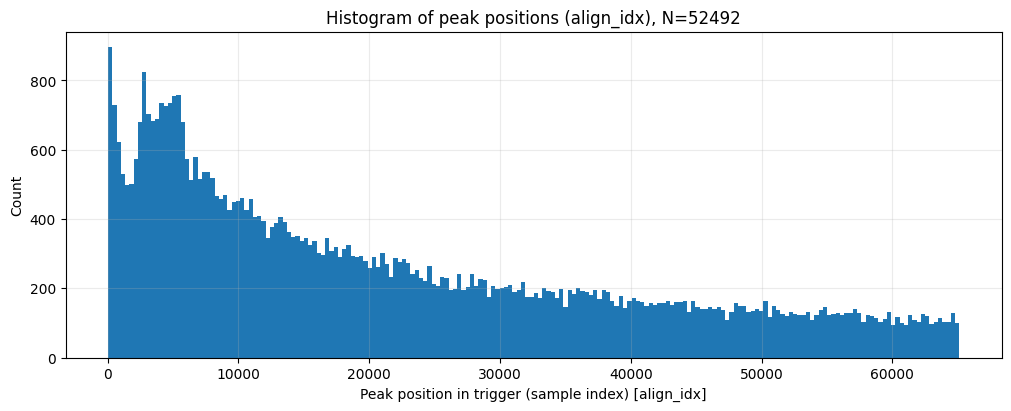

In [29]:
psel.plot_peak_position_histogram(
    pulse_ds,
    # use="argmax",
    use="align",
    bins=200
);

In [30]:
# pulse_ds.keys()

In [31]:
# plt.hist(pulse_ds['align_idx'], bins=100, range=(0, 10000));
# plt.grid()

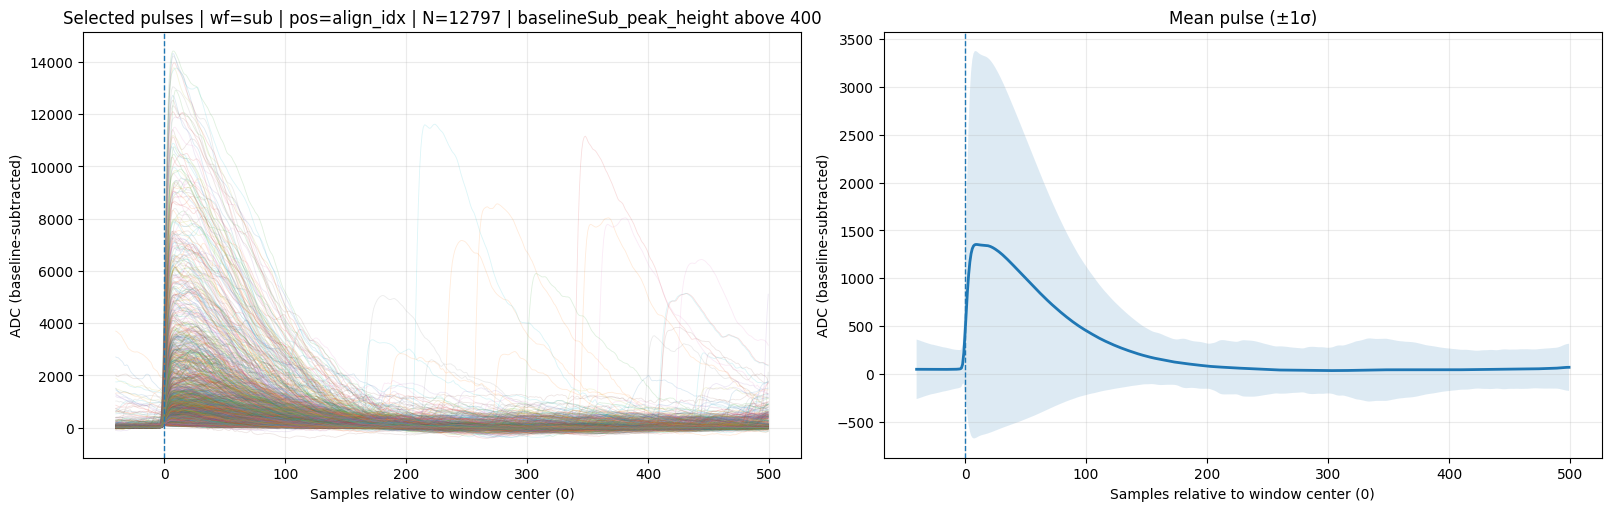

In [32]:
_, _, _, _ = psel.plot_pulses(
    pulse_ds,
    waveform="sub",
    use_pos="align",
    pos_side="none",  pos_cut=None,
    amp_side="above", amp_cut=400,
    ADCsat=None,
    show_plot=True
)


In [33]:
# _, _, _, _ = psel.plot_pulses(
#     pulse_ds,
#     waveform="sub",
#     use_pos="align",

#     pos_side="before", pos_cut=6000,
#     amp_side="above", amp_cut=400,
    
#     ADCsat=None
# )


In [34]:
# _, _, _, _ = psel.plot_pulses(
#     pulse_ds,
#     waveform="sub",
#     use_pos="align",

#     pos_side="before", pos_cut=30000,
#     amp_side="above",  amp_cut=400,
    
#     ADCsat=None
# )

31273 5034 14192


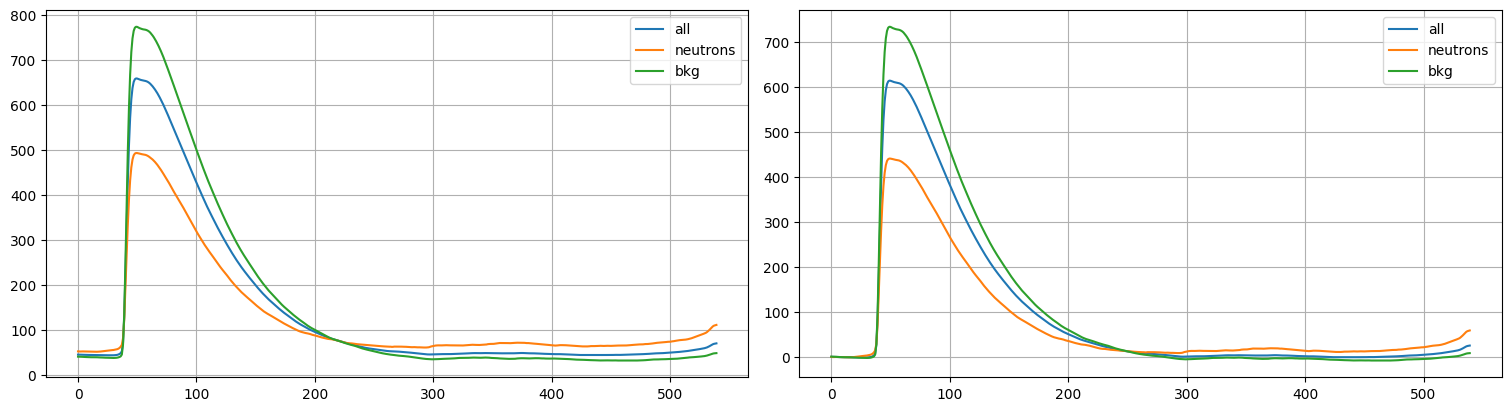

In [35]:
ADCrange = (200,1e6)
# ADCrange = (200, 4000)
bg_range = (20000, 65600)
# trigger_length = 65600

_, meta_all, mean_all, _ = psel.plot_pulses(pulse_ds,waveform="sub",use_pos="align",ADCsat=None,show_plot=False,
    pos_side="none",  pos_cut=None,
    amp_side="between", amp_cut=ADCrange,
)
_, meta_n, mean_n, _ = psel.plot_pulses(pulse_ds,waveform="sub",use_pos="align",ADCsat=None,show_plot=False,
    pos_side="between", pos_cut=(2000, 6000),
    amp_side="between", amp_cut=ADCrange,
)
_, meta_bkg, mean_bkg, _ = psel.plot_pulses(pulse_ds,waveform="sub",use_pos="align",ADCsat=None,show_plot=False,
    pos_side="between",  pos_cut=bg_range,
    amp_side="between", amp_cut=ADCrange,
)

print(len(meta_all['index']), len(meta_n['index']), len(meta_bkg['index']) )

fig, ax = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)
ax[0].plot(mean_all,   label='all')
ax[0].plot(mean_n,     label='neutrons')
ax[0].plot(mean_bkg,  label='bkg')
ax[1].plot(bsub(mean_all),   label='all')
ax[1].plot(bsub(mean_n),     label='neutrons')
ax[1].plot(bsub(mean_bkg),  label='bkg')
ax[0].grid();
ax[1].grid();
ax[0].legend();
ax[1].legend();


In [13]:
# ADCrange = (200,1e6)
# # trigger_length = 65600

# _, meta_all, mean_all, _ = psel.plot_pulses(pulse_ds,waveform="sub",use_pos="align",ADCsat=None,show_plot=False,
#     pos_side="none",  pos_cut=None,
#     amp_side="between", amp_cut=ADCrange,
# )
# _, meta_n, mean_n, _ = psel.plot_pulses(pulse_ds,waveform="sub",use_pos="align",ADCsat=None,show_plot=False,
#     pos_side="between", pos_cut=(2000, 6000),
#     amp_side="between", amp_cut=ADCrange,
# )
# _, meta_bkg1, mean_bkg1, _ = psel.plot_pulses(pulse_ds,waveform="sub",use_pos="align",ADCsat=None,show_plot=False,
#     pos_side="between",  pos_cut=(10000, 20000),
#     amp_side="between", amp_cut=ADCrange,
# )
# _, meta_bkg2, mean_bkg2, _ = psel.plot_pulses(pulse_ds,waveform="sub",use_pos="align",ADCsat=None,show_plot=False,
#     pos_side="between",  pos_cut=(20000, 30000),
#     amp_side="between", amp_cut=ADCrange,
# )
# _, meta_bkg3, mean_bkg3, _ = psel.plot_pulses(pulse_ds,waveform="sub",use_pos="align",ADCsat=None,show_plot=False,
#     pos_side="between",  pos_cut=(30000, 50000),
#     amp_side="between", amp_cut=ADCrange,
# )
# _, meta_bkg4, mean_bkg4, _ = psel.plot_pulses(pulse_ds,waveform="sub",use_pos="align",ADCsat=None,show_plot=False,
#     pos_side="between",  pos_cut=(50000, 65600),
#     amp_side="between", amp_cut=ADCrange,
# )

# print(len(meta_all['index']), len(meta_n['index']), len(meta_bkg1['index']), len(meta_bkg2['index']), len(meta_bkg3['index']), len(meta_bkg4['index']) )

# fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)
# ax.plot(mean_all,  label='all')
# ax.plot(mean_n,    label='neutrons')
# ax.plot(mean_bkg1, label='bkg1');
# ax.plot(mean_bkg2, label='bkg2');
# ax.plot(mean_bkg3, label='bkg3');
# ax.plot(mean_bkg4, label='bkg4');
# # ax.set_ylim(0, 1250)
# ax.grid();
# ax.legend();

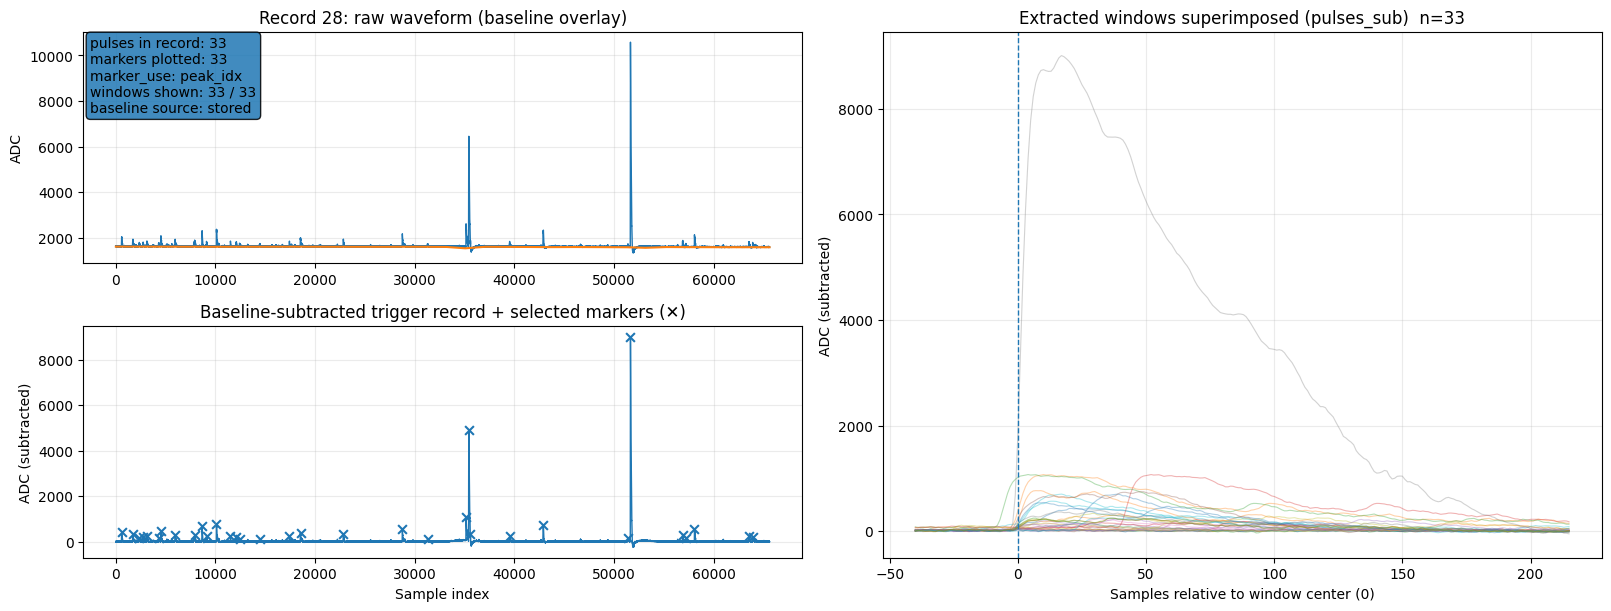

In [14]:

W_rec, idx = psel.plot_record(
    raw_wfs, pulse_ds,
    record_index=28,
    marker_use="peak_idx",
    # max_pulses_to_plot=1, 
)

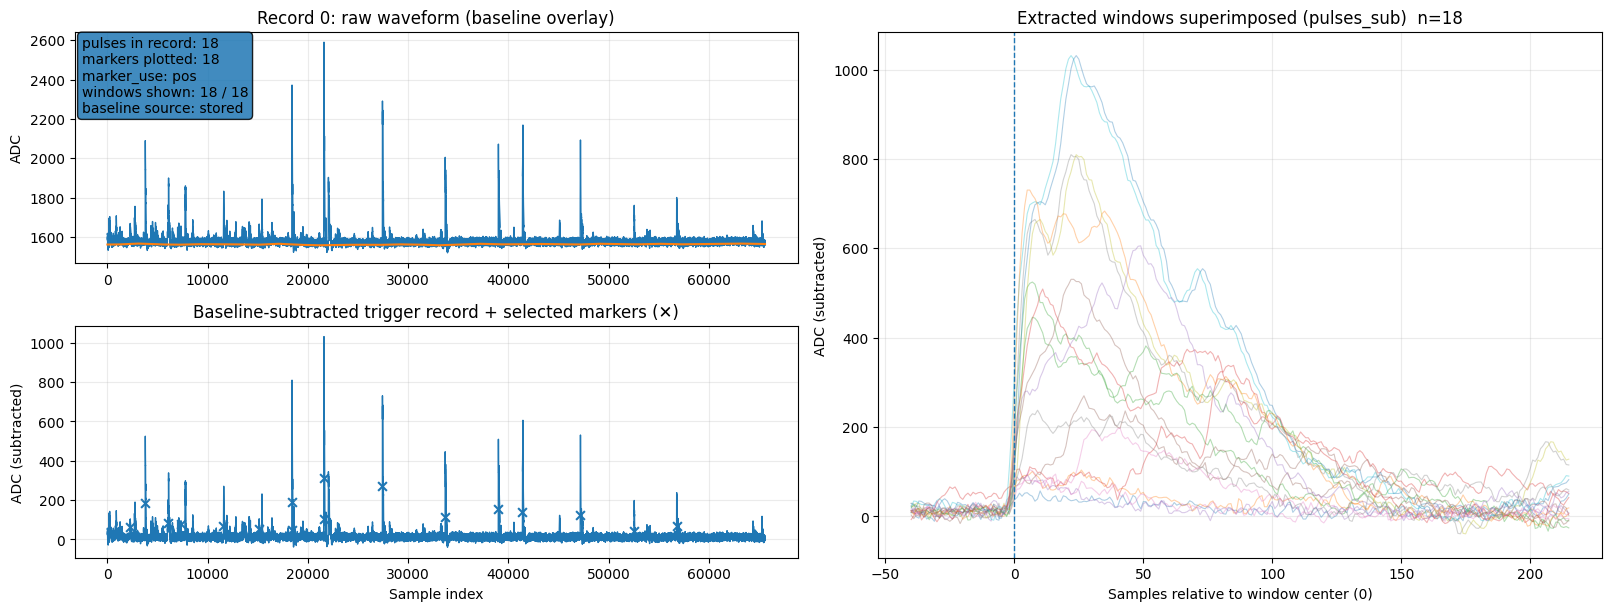

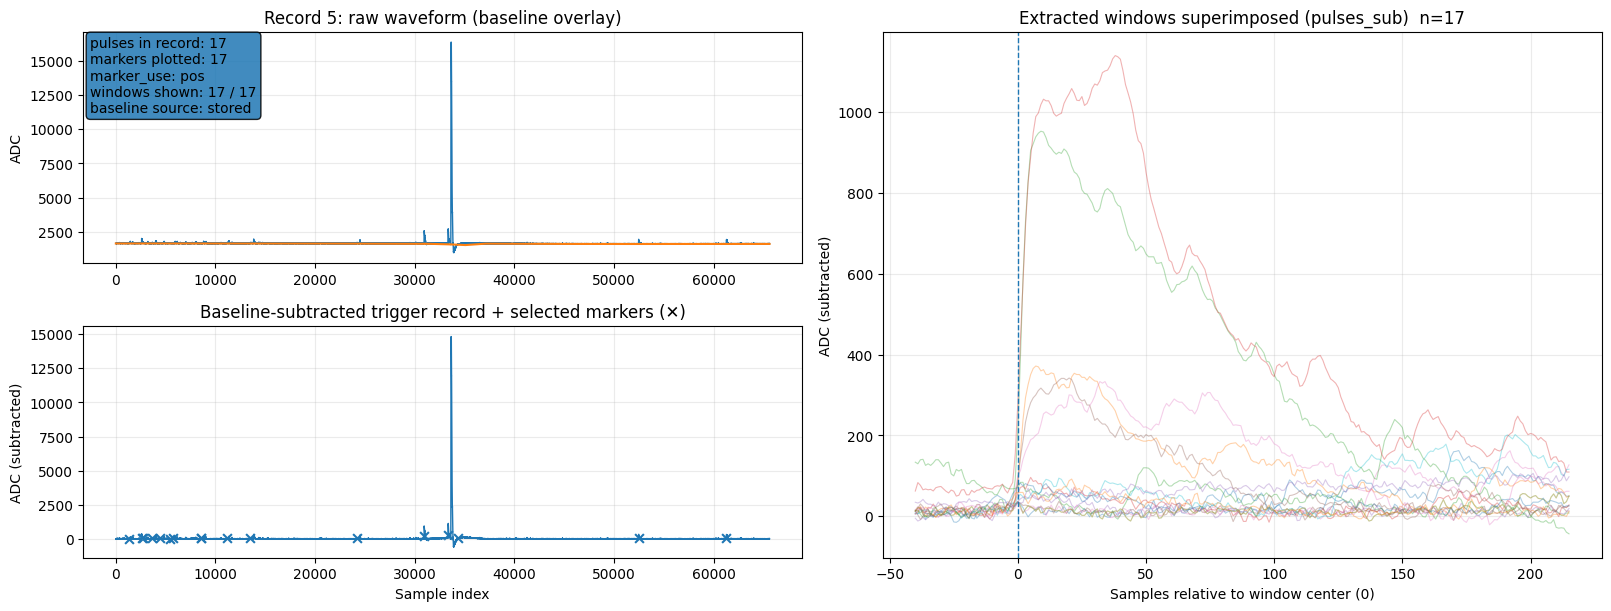

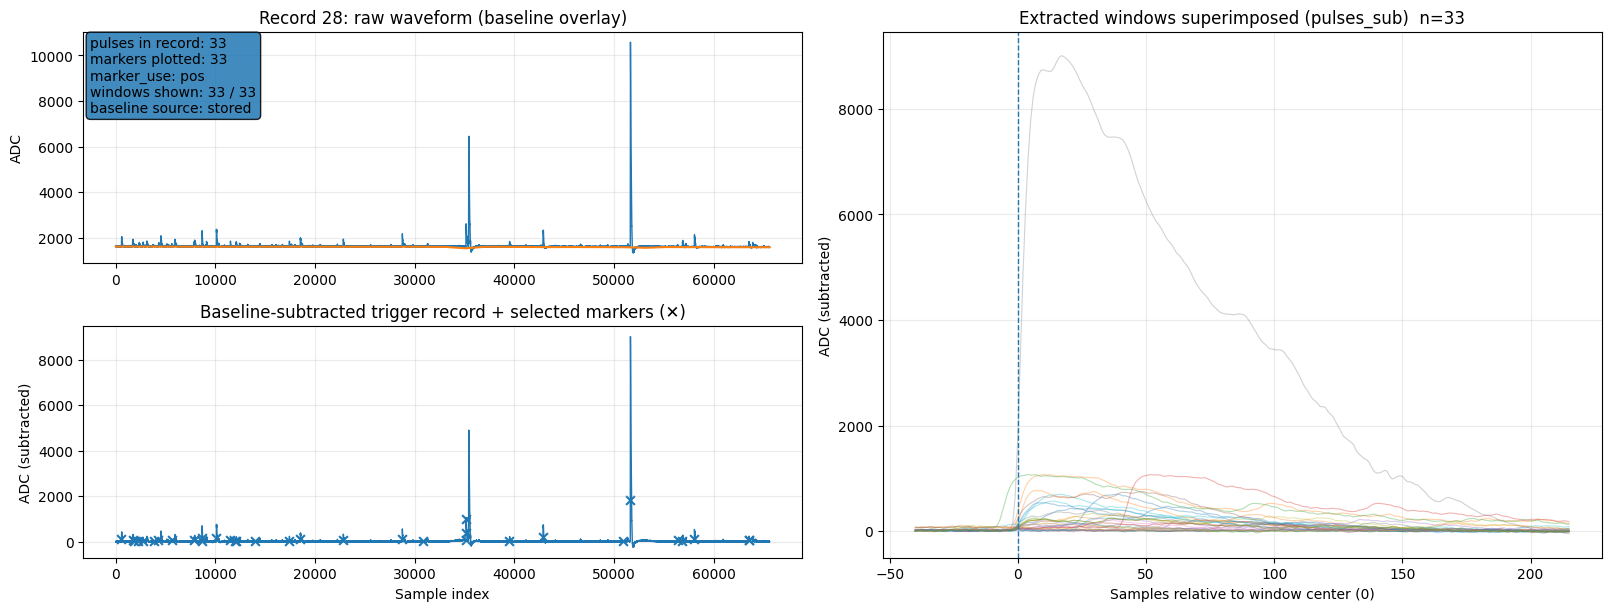

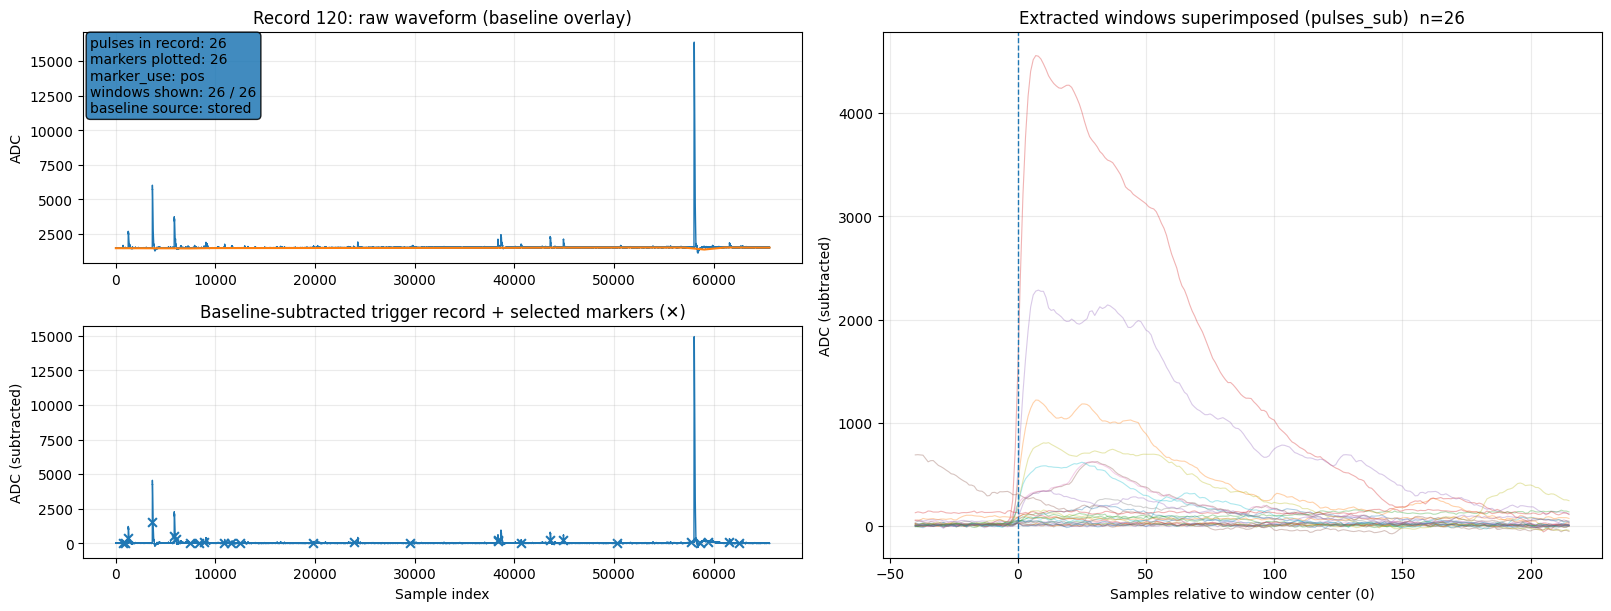

In [15]:
for ri in [0, 5, 28, 120]:
    psel.plot_record(raw_wfs, pulse_ds, record_index=ri, max_pulses_to_plot=200)